# 项目 2-2（★）构造 XOR，证明感知机之死

- **练到**：线性可分 vs 不可分、局限
- **数据**：构造 4 个样本（00→0、01→1、10→1、11→0），即 XOR（笔记第 4 节"深度学习的寒冬"）。
- **任务**：用项目 2-1 的感知机去训练，观察 loss 永远降不到 0；用 matplotlib 画出 4 个点，验证"不存在一条直线能分开它们"。
- **验收**：训练收敛不了（或震荡）、准确率≤75%；报告里写清楚为什么单层做不到。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# ========== 2.1 中的感知机 ==========
class Perceptron:
    def __init__(self, lr=0.1, iterations=100):
        self.lr = lr                 # 学习率 η
        self.iterations = iterations # 最大迭代轮数
        self.w = None                # 权重 [w1, w2]
        self.b = None                # 偏置
        self.history = []            # 保存每轮 w, b，用来画决策边界变化

    def predict(self, x):
        # 计算加权和：z = w1·x1 + w2·x2 + b
        z = np.dot(self.w, x) + self.b
        return 1 if z >= 0 else 0

    def fit(self, X, y):
        _, n_features = X.shape

        # 权重、偏置全部初始化为 0
        self.w = np.zeros(n_features)
        self.b = 0.0

        for epoch in range(self.iterations):
            error_count = 0 # 本轮错误样本计数

            for xi, yi in zip(X, y):
                y_hat = self.predict(xi)

                # 如果预测错误，执行感知机更新规则
                if y_hat != yi:
                    e = yi - y_hat
                    self.w += self.lr * e * xi
                    self.b += self.lr * e
                    error_count += 1

            # 保存本轮参数
            self.history.append((self.w.copy(), self.b))

            # 打印进度
            print(f"epoch {epoch:2d} | error_count: {error_count} | w = {np.round(self.w, 4)}, b = {np.round(self.b, 4)}")

            # 全部样本预测正确，提前停止
            if error_count == 0:
                print(f"✅全部样本分类正确，提前结束训练，共迭代 {epoch+1} 轮")
                break

        return self

In [3]:
# ========== 构造 XOR 数据 ==========
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y = np.array([0, 1, 1, 0])

In [4]:
# ========== 开始训练 ==========
model = Perceptron(lr=0.01, iterations=100)
model.fit(X, y)

# 计算训练集准确率
correct = 0
for xi, yi in zip(X, y):
    if model.predict(xi) == yi:
        correct += 1

acc = correct / len(y)
print(f"训练集准确率：{acc:.2%}")
print(f"最终权重 [w1 w2] = {np.round(model.w, 4)}")
print(f"最终偏置 b = {np.round(model.b, 4)}")

epoch  0 | error_count: 3 | w = [-0.01  0.  ], b = -0.01
epoch  1 | error_count: 3 | w = [-0.01  0.  ], b = 0.0
epoch  2 | error_count: 4 | w = [-0.01  0.  ], b = 0.0
epoch  3 | error_count: 4 | w = [-0.01  0.  ], b = 0.0
epoch  4 | error_count: 4 | w = [-0.01  0.  ], b = 0.0
epoch  5 | error_count: 4 | w = [-0.01  0.  ], b = 0.0
epoch  6 | error_count: 4 | w = [-0.01  0.  ], b = 0.0
epoch  7 | error_count: 4 | w = [-0.01  0.  ], b = 0.0
epoch  8 | error_count: 4 | w = [-0.01  0.  ], b = 0.0
epoch  9 | error_count: 4 | w = [-0.01  0.  ], b = 0.0
epoch 10 | error_count: 4 | w = [-0.01  0.  ], b = 0.0
epoch 11 | error_count: 4 | w = [-0.01  0.  ], b = 0.0
epoch 12 | error_count: 4 | w = [-0.01  0.  ], b = 0.0
epoch 13 | error_count: 4 | w = [-0.01  0.  ], b = 0.0
epoch 14 | error_count: 4 | w = [-0.01  0.  ], b = 0.0
epoch 15 | error_count: 4 | w = [-0.01  0.  ], b = 0.0
epoch 16 | error_count: 4 | w = [-0.01  0.  ], b = 0.0
epoch 17 | error_count: 4 | w = [-0.01  0.  ], b = 0.0
epoch 18

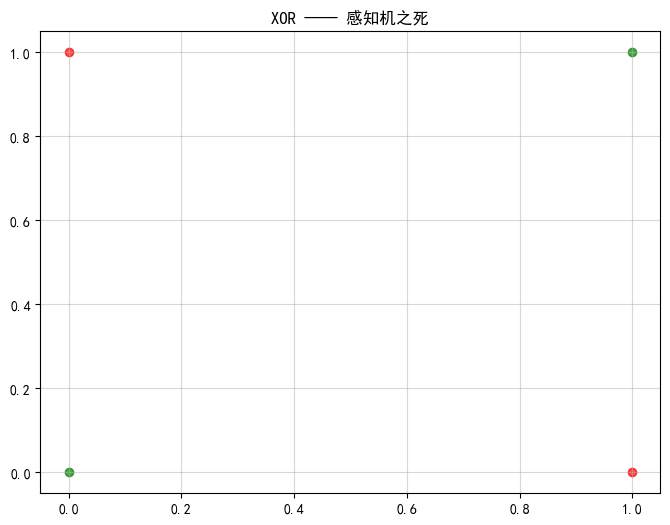

In [6]:
plt.figure(figsize=(8, 6))
mask0 = (y == 0)
mask1 = (y == 1)
plt.scatter(X[mask0, 0], X[mask0, 1], c="green", alpha=0.7)
plt.scatter(X[mask1, 0], X[mask1, 1], c="red", alpha=0.7)

plt.title("XOR —— 感知机之死")
plt.grid(alpha=0.5)
plt.show()